<a href="https://colab.research.google.com/github/Abeeraiftikhar/AI_and_Drug_Discovery_Course_2026/blob/main/Assignment_3_part3_QSAR_Part_4_Regression_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AI And Biotechnology/Bioinformatics**

## **AI and Drug Discovery Course: QSAR Modeling**
This notebook demonstrates how to build **Random forest Regression model** to predict pIC50 values.

In [4]:
# Install LazyPredict
!pip install lazypredict


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.0 MB/s eta 0:00:00


In [5]:
# Install SHAP
!pip install shap

In [6]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.utils import shuffle
from lazypredict.Supervised import LazyRegressor
import shap

## **Loading the Dataset**

In [7]:
df = pd.read_csv('QSAR_dataset.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL340270,inactive,4.931814,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL6063904,active,7.677781,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL5182395,active,7.187087,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL5820135,active,8.346787,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL5843645,active,7.045757,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Dataset overview:**
- `molecule_chembl_id`: Unique molecule ID
- `bioactivity_class`: Active/inactive class
- `pIC50`: Continuous potency value (4-9)
- `PubchemFP0` to `PubchemFP880`: 881 binary fingerprints

We have 2443 molecules and 881 features plus 3 identifier/target columns.

## **Features (X) and Target (y)**

Features are our PubChem fingerprints. Target is pIC50 for regression.
We'll exclude non-feature columns first.

In [8]:
# Exclude non-feature columns
non_feature_cols = ['molecule_chembl_id', 'bioactivity_class', 'pIC50']
X = df.drop(columns=non_feature_cols)
print(X.shape)

(1988, 881)


In [9]:
# Target variable
y_reg = df['pIC50']
y_reg

,pIC50
0,4.931814
1,7.677781
2,7.187087
3,8.346787
4,7.045757
...,...
1983,8.301030
1984,7.677781
1985,4.853872
1986,4.698970


## **Feature Selection – Variance Threshold**

Not all 881 fingerprints are informative. Low-variance features (mostly 0 or 1) add noise. We remove them using `VarianceThreshold`.

In [10]:
# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (1988, 158)


In [11]:
881 - 151

730

**Result:** 151 informative features retained, 730 removed. Reduces noise, speeds up training, and improves generalization.

## **Split Data into Training and Test Set**

In [12]:
# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Training set size: 1590 molecules
Testing set size: 398 molecules


## **Build and Train Random Forest Model**

In [13]:
# Set random seed for reproducibility
np.random.seed(123)

# Create Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200)

# Train model
rf_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=200)

## **Evaluate Model's Performance on Test Set**

In [14]:
r2 = rf_model.score(X_test_reg, y_test_reg)
print(f'Random Forest R² score: {r2:.4f}')

Random Forest R² score: 0.7070


## **R² interpretation:**
- **R² < 0.4** → Poor fit.
- **R² < 0.5-0.7** → Moderate/Acceptable.
- **R² > 0.9** → Very good/High fit

Other metrics like **RMSE** or **MAE** can also be used.

## **Make Predictions on test set**

In [15]:
# Predict on test set
y_pred_reg = rf_model.predict(X_test_reg)

In [16]:
y_pred_reg

array([6.21136009, 7.6385081 , 7.73395401, 7.91838542, 8.06597853,
       8.17177574, 6.62387833, 8.1675924 , 8.29936588, 8.11416411,
       4.69897   , 7.77495584, 7.76190722, 8.53153241, 7.14331408,
       7.3590798 , 8.3984318 , 8.08357102, 7.77943235, 7.03566948,
       6.35895956, 8.28358548, 7.5789921 , 7.37087037, 8.07128173,
       9.31250244, 8.03194269, 7.50987991, 7.70059598, 7.61039609,
       8.03194269, 8.09925858, 8.77839931, 9.33720837, 7.05169445,
       6.71221647, 8.3274086 , 8.39566303, 7.45324012, 7.89298137,
       7.62552473, 8.48437309, 6.31006905, 7.36462318, 6.69126585,
       7.56147443, 8.51897246, 8.02792415, 8.3984318 , 9.32666723,
       9.28257935, 5.38849337, 7.91268135, 7.59737451, 8.48437309,
       7.41124845, 6.2109294 , 8.38187232, 7.67904427, 7.79916082,
       7.94335752, 8.59752873, 7.36436841, 8.06628619, 7.37353553,
       7.73367729, 6.81994582, 7.62631388, 6.67158904, 4.36329418,
       7.78447122, 7.89219976, 9.29292327, 7.02476275, 7.55877

**y_test_reg**       ..............# actual pIC50  
**y_pred_reg**       ..............# predicted pIC50 values from model

## **Visualize Predictions vs Actual Values**



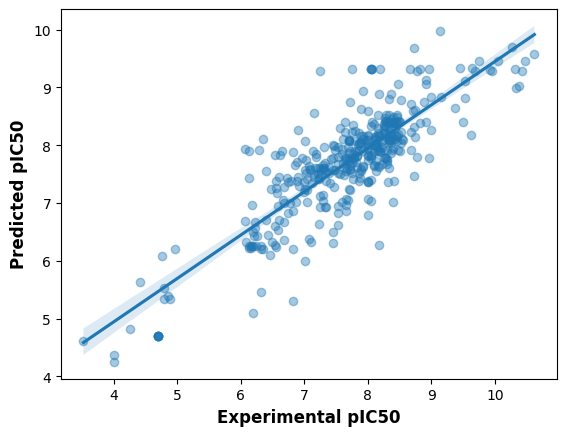

In [17]:
ax = sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
plt.show()

## **Y-Randomization – Validate Model**

In [18]:
n_iterations = 5
random_r2_scores = []

for i in range(n_iterations):
    y_train_shuffled = shuffle(y_train_reg, random_state=i)
    rf_random = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg, y_train_shuffled)
    y_pred_random = rf_random.predict(X_test_reg)
    r2_random = r2_score(y_test_reg, y_pred_random)
    random_r2_scores.append(r2_random)

print('\nY-Randomization Test Results:')
print(f'Mean R² with shuffled Y: {np.mean(random_r2_scores):.4f}')
print(f'Actual RF R²: {r2:.4f}')


Y-Randomization Test Results:
Mean R² with shuffled Y: -0.3257
Actual RF R²: 0.7070


### **Interpretation:**
- Actual RF R² = 0.5,   
- Random R² ≈ -0.2 → Model is learning real chemical patterns, not noise.

## **LazyPredict – Compare Multiple Regression Models**

In [19]:
print('\n' + '='*60)
print('LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS')
print('='*60)

# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit all models
models, predictions = reg.fit(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

# Display results
print(models.head(10))  # Top 10 models


LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
HistGradientBoostingRegressor            0.522746   0.712686  0.574424   
RandomForestRegressor                    0.506975   0.703192  0.583838   
LGBMRegressor                            0.492601   0.694538  0.592287   
BaggingRegressor                         0.485595   0.690321  0.596362   
SVR                                      0.466602   0.678886  0.607272   
XGBRegressor                             0.459776   0.674777  0.611145   
NuSVR                                    0.456952   0.673077  0.612741   
GradientBoostingRegressor                0.452937   0.670660  0.615001   
KNeighborsRegressor                      0.417252   0.649177  0.634743   
MLPRegressor                             0.379879   0.626678  0.654780   

                               Time Taken  
Model          

## **Visualize Top Models**

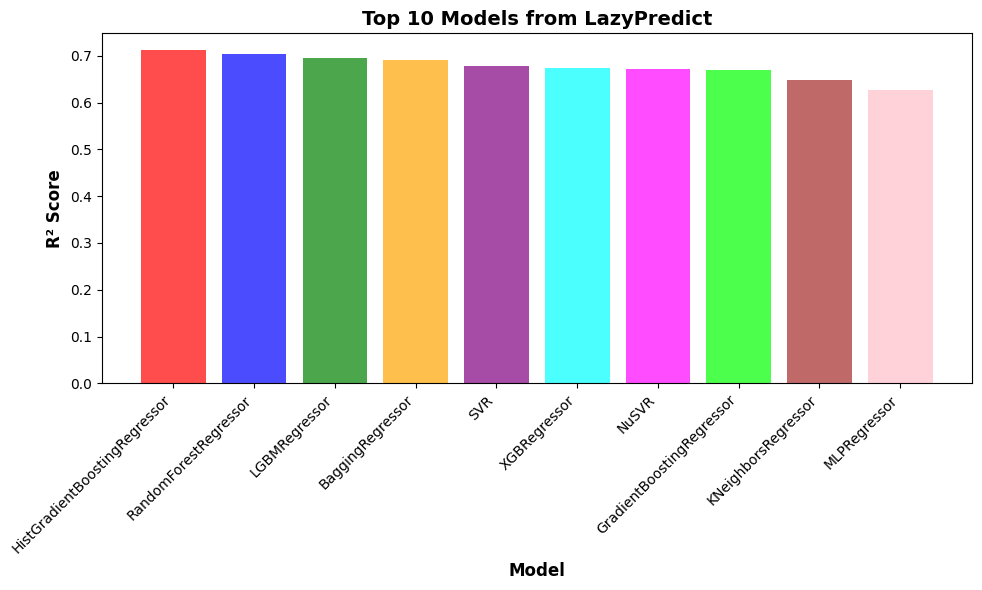

In [20]:
top_models = models.head(10)

plt.figure(figsize=(10, 6))

# Define distinct colors for each bar
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'brown', 'pink']

# Vertical bar plot with multiple colors and alpha for transparency
plt.bar(top_models.index, top_models['R-Squared'], color=colors, alpha=0.7)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Top 10 Models from LazyPredict', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **Compare Best Model with Random Forest**

In [21]:
best_model_name = models.index[0]
best_r2 = models['R-Squared'].iloc[0]
print(f'Best model from LazyPredict: {best_model_name}')
print(f'Best R² score: {best_r2:.4f}')
print(f'Random Forest R²: {r2:.4f}')
print(f'Improvement: {(best_r2 - r2)*100:.2f}%')

# Check Random Forest rank
if 'RandomForestRegressor' in models.index:
    rf_rank = models.index.get_loc('RandomForestRegressor') + 1
    print(f'Random Forest ranked: {rf_rank} out of {len(models)}')

Best model from LazyPredict: HistGradientBoostingRegressor
Best R² score: 0.7127
Random Forest R²: 0.7070
Improvement: 0.57%
Random Forest ranked: 2 out of 42


## **Random Forest Feature Importances using SHAP values**

/tmp/ipykernel_1839/1758221937.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)


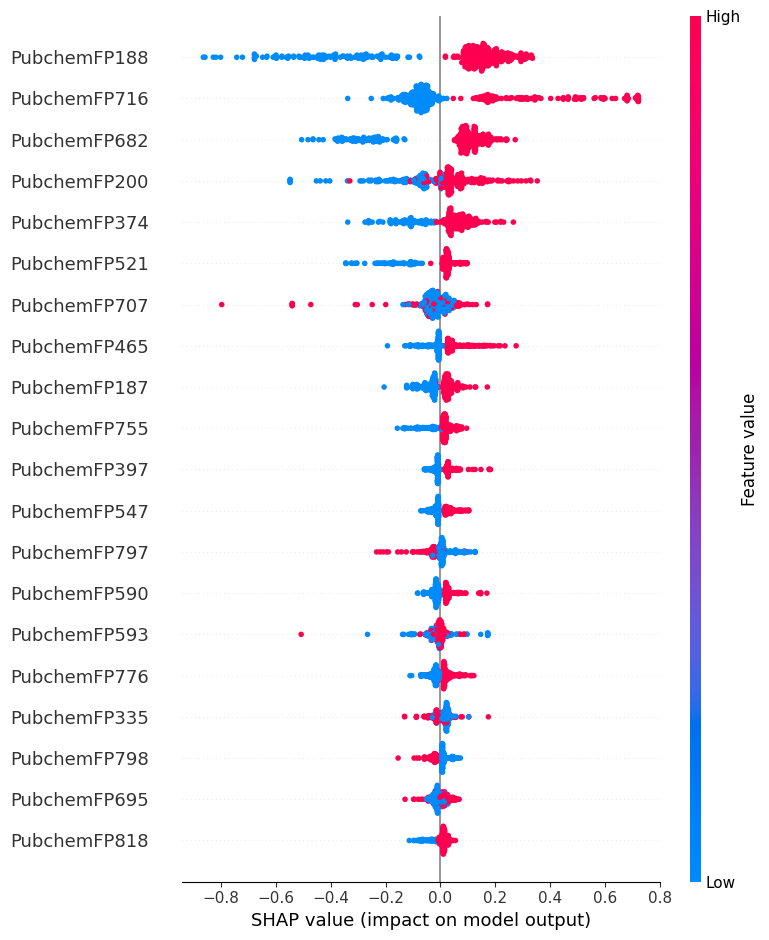

In [22]:
# Create an explainer and calculate SHAP values for the test set
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_reg)

# Summary plot
shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')